In [1]:
# Breast Cancer Analysis — Python
# Author: Saima Imran
# Date: April 2026

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Load and explore the breast cancer dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target
df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

print("Dataset shape:", df.shape)
print("\nDiagnosis distribution:")
print(df['diagnosis_label'].value_counts())
print("\nFirst 5 rows:")
df.head()

Dataset shape: (569, 32)

Diagnosis distribution:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


C:\Users\saima\AppData\Local\Temp\ipykernel_18880\1952474859.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='diagnosis_label',


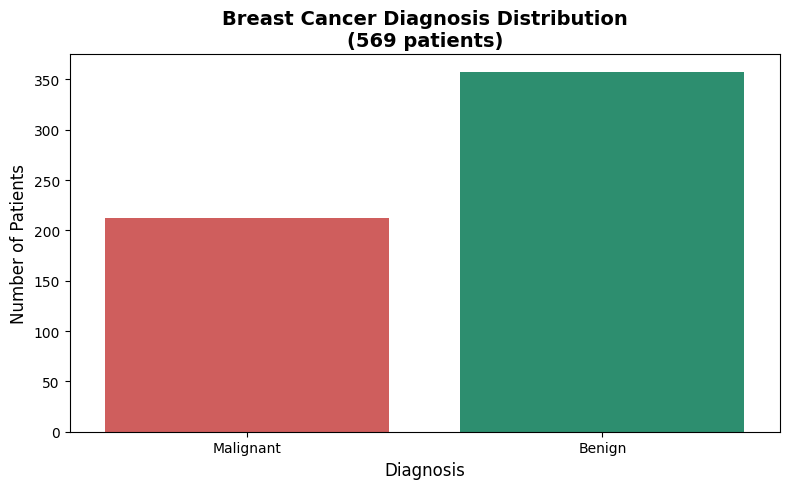

Plot saved!


In [3]:
# Visualisation 1 — Diagnosis Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='diagnosis_label', 
              palette=['#E24B4A', '#1D9E75'])
plt.title('Breast Cancer Diagnosis Distribution\n(569 patients)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.tight_layout()
plt.savefig('diagnosis_distribution.png', dpi=150)
plt.show()
print("Plot saved!")

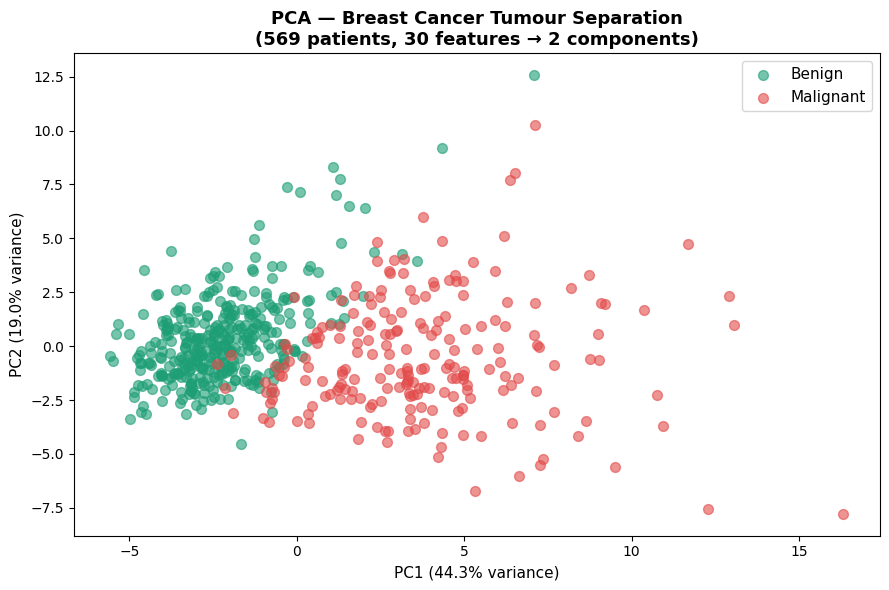

PCA plot saved!


In [4]:
# Visualisation 2 — PCA Plot
scaler = StandardScaler()
X = df[data.feature_names]
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['diagnosis_label'] = df['diagnosis_label']

plt.figure(figsize=(9, 6))
colors = {'Malignant': '#E24B4A', 'Benign': '#1D9E75'}
for diagnosis, group in pca_df.groupby('diagnosis_label'):
    plt.scatter(group['PC1'], group['PC2'], 
                label=diagnosis, 
                color=colors[diagnosis], 
                alpha=0.6, s=50)

plt.title('PCA — Breast Cancer Tumour Separation\n(569 patients, 30 features → 2 components)', 
          fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150)
plt.show()
print("PCA plot saved!")

In [5]:
# Machine Learning — Random Forest Classifier
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, df['diagnosis'], test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

cv_scores = cross_val_score(rf, X_scaled, df['diagnosis'], cv=5)
y_pred = rf.predict(X_test)
auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print("Classification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Malignant', 'Benign']))
print(f"5-fold Cross-validated AUC: {auc:.3f}")
print(f"Mean CV Score: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

Task was destroyed but it is pending!
task: <Task pending name='Task-249' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\saima\AppData\Roaming\Python\Python313\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-250' coro=<Kernel.shell_main() running at C:\Users\saima\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\saima\AppData\Roaming\Python\Python313\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\ProgramData\miniconda3\Lib\inspect.py:3098: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  params = OrderedDict((param.name, param) for param in parameters)
Task was destroyed but it is pending!
task: <Task pending name='Task-250' coro=<Kernel.shell_main() running at C:\Users\saima\AppData\Roaming\Python\Python313\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.93      0.95        43
      Benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

5-fold Cross-validated AUC: 0.995
Mean CV Score: 0.956 (+/- 0.023)


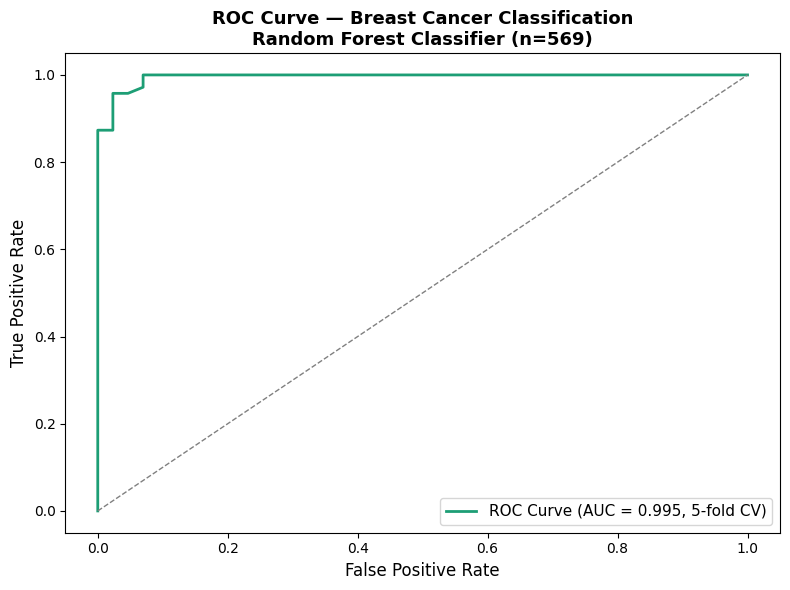

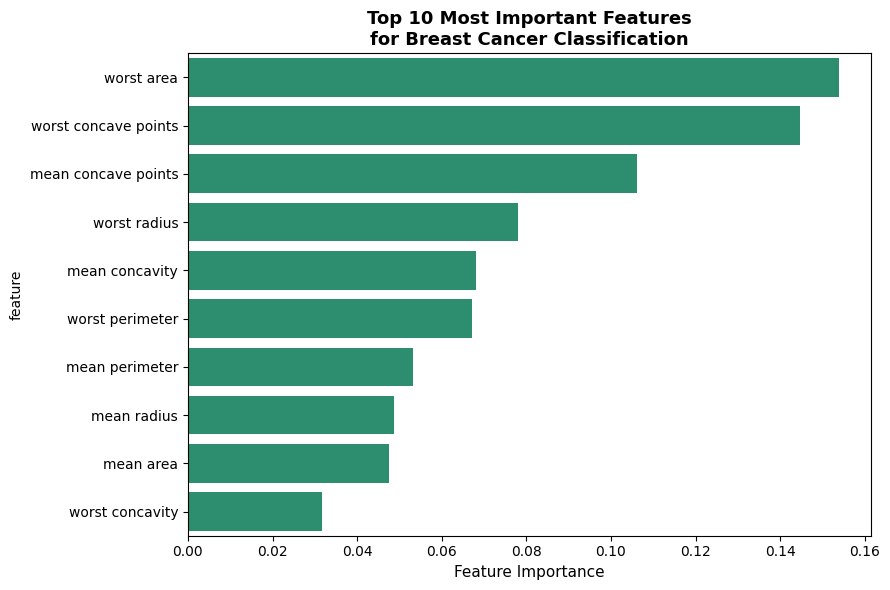

All plots saved! Project complete.


In [6]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1D9E75', lw=2, 
         label=f'ROC Curve (AUC = 0.995, 5-fold CV)')
plt.plot([0,1], [0,1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Breast Cancer Classification\nRandom Forest Classifier (n=569)', 
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

# Feature importance
feat_imp = pd.DataFrame({
    'feature': data.feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', color='#1D9E75')
plt.title('Top 10 Most Important Features\nfor Breast Cancer Classification', 
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=11)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("All plots saved! Project complete.")